In [1]:
import os
import sys
import joblib

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from utils.models import build_model
from utils.preprocessing import (
    FEATURES,
    filter_labels
)
from utils.evaluation import evaluate_model
from property_factory import build_properties
import property_driven_ml.logics as pml_logics

In [2]:
# =========================
# Define datasets
# =========================
df_cicids_combined_train = pd.read_csv("../data/cicids_combined_balanced_train.tsv", on_bad_lines="skip", delimiter="\t")
df_cicids_combined_test = pd.read_csv("../data/cicids_combined_test.tsv", on_bad_lines="skip", delimiter="\t")
df_ciciot2023_train = pd.read_csv("../data/ciciot2023_balanced_train.tsv", on_bad_lines="skip", delimiter="\t")
df_ciciot2023_test = pd.read_csv("../data/ciciot2023_test.tsv", on_bad_lines="skip", delimiter="\t")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
TARGET_LABELS = ["BENIGN", "PORTSCAN", "DOS_HTTP_FLOOD", "ATTACK"]
MODEL_TYPES = [
    "mlp", 
    # "cnnlstm"
]
BATCH_SIZE = 256
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3
LAMBDA_PROP = 0.3
WINDOW_SECONDS = 5.0

In [4]:
df_cicids_combined_train_filtered = filter_labels(df_cicids_combined_train, TARGET_LABELS)
df_cicids_combined_test_filtered = filter_labels(df_cicids_combined_test, TARGET_LABELS)
df_ciciot2023_train_filtered = filter_labels(df_ciciot2023_train, TARGET_LABELS)
df_ciciot2023_test_filtered = filter_labels(df_ciciot2023_test, TARGET_LABELS)

In [5]:
DATASETS = {
    "cicids_combined": {
        "data_train": df_cicids_combined_train_filtered,
        "data_test": df_cicids_combined_test_filtered
    },
    "ciciot2023": {
        "data_train": df_ciciot2023_train_filtered,
        "data_test": df_ciciot2023_test_filtered
    },
}


TRAINING ON: CICIDS_COMBINED
Shape: (431296, 36)
label
BENIGN            107824
PORTSCAN          107824
DOS_HTTP_FLOOD    107824
ATTACK            107824
Name: count, dtype: int64
Features: 35
['proto', 'service', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'orig_pkt_rate', 'orig_byte_rate', 'pkt_asymmetry', 'byte_asymmetry', 'time_elapsed', 'flood_rate', 'valid_tcp_handshake_feature', 'is_http', 'uniq_dst_ports', 'pkts_per_port', 'scan_duration', 'fail_ratio', 'is_udp', 'udp_conn_count', 'udp_packets', 'udp_rate', 'unique_src_ips', 'syn_duration', 'syn_conn_count', 'syn_count', 'syn_rate', 'half_open_count', 'source_ip_count']
Building properties for logic: DL2
Initial property loss:  0.03691564127802849
Initial property sat:  0.27968502044677734
Property stats: {'DOS_HTTP_FLOOD_loss': 0.0047156005166471004, 'DOS_HTTP_FLOOD_sat': 0.5199999809265137, 'DOS_HTTP_FLOOD_active_frac': 0.097656

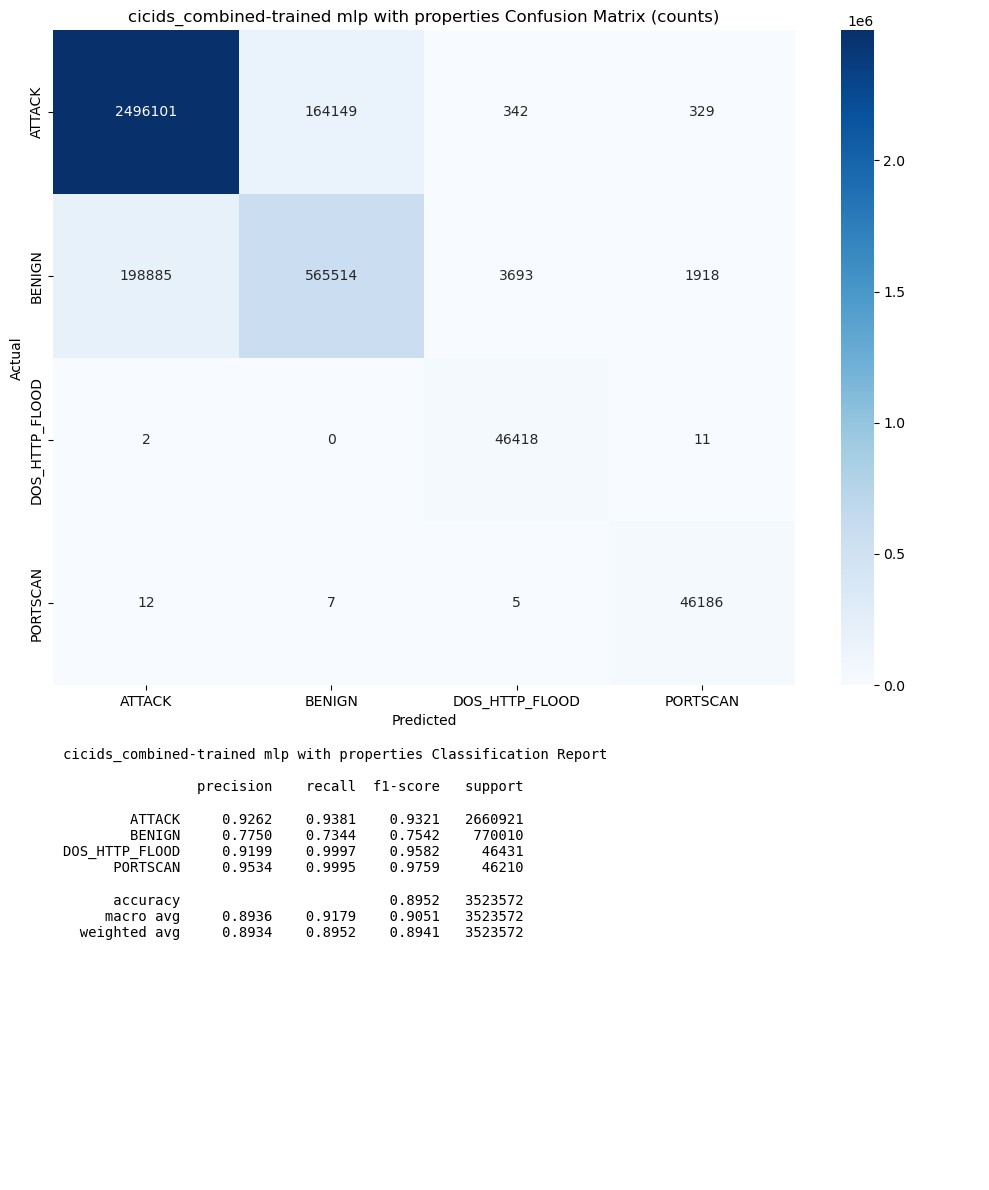


Saved model to: models/mlp_property_cicids_combined.joblib


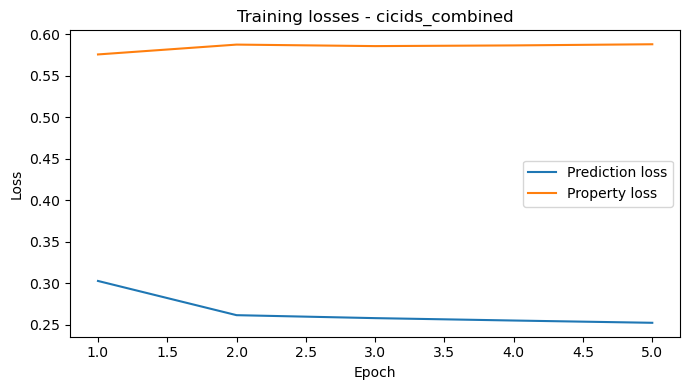


TRAINING ON: CICIOT2023
Shape: (606292, 36)
label
ATTACK            151573
DOS_HTTP_FLOOD    151573
PORTSCAN          151573
BENIGN            151573
Name: count, dtype: int64
Features: 35
['proto', 'service', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'orig_pkt_rate', 'orig_byte_rate', 'pkt_asymmetry', 'byte_asymmetry', 'time_elapsed', 'flood_rate', 'valid_tcp_handshake_feature', 'is_http', 'uniq_dst_ports', 'pkts_per_port', 'scan_duration', 'fail_ratio', 'is_udp', 'udp_conn_count', 'udp_packets', 'udp_rate', 'unique_src_ips', 'syn_duration', 'syn_conn_count', 'syn_count', 'syn_rate', 'half_open_count', 'source_ip_count']
Building properties for logic: DL2
Initial property loss:  0.027836192399263382
Initial property sat:  0.29360464215278625
Property stats: {'DOS_HTTP_FLOOD_loss': 0.0426018089056015, 'DOS_HTTP_FLOOD_sat': 0.0, 'DOS_HTTP_FLOOD_active_frac': 0.015625, 'DOS_HTTP_FLOOD_vali

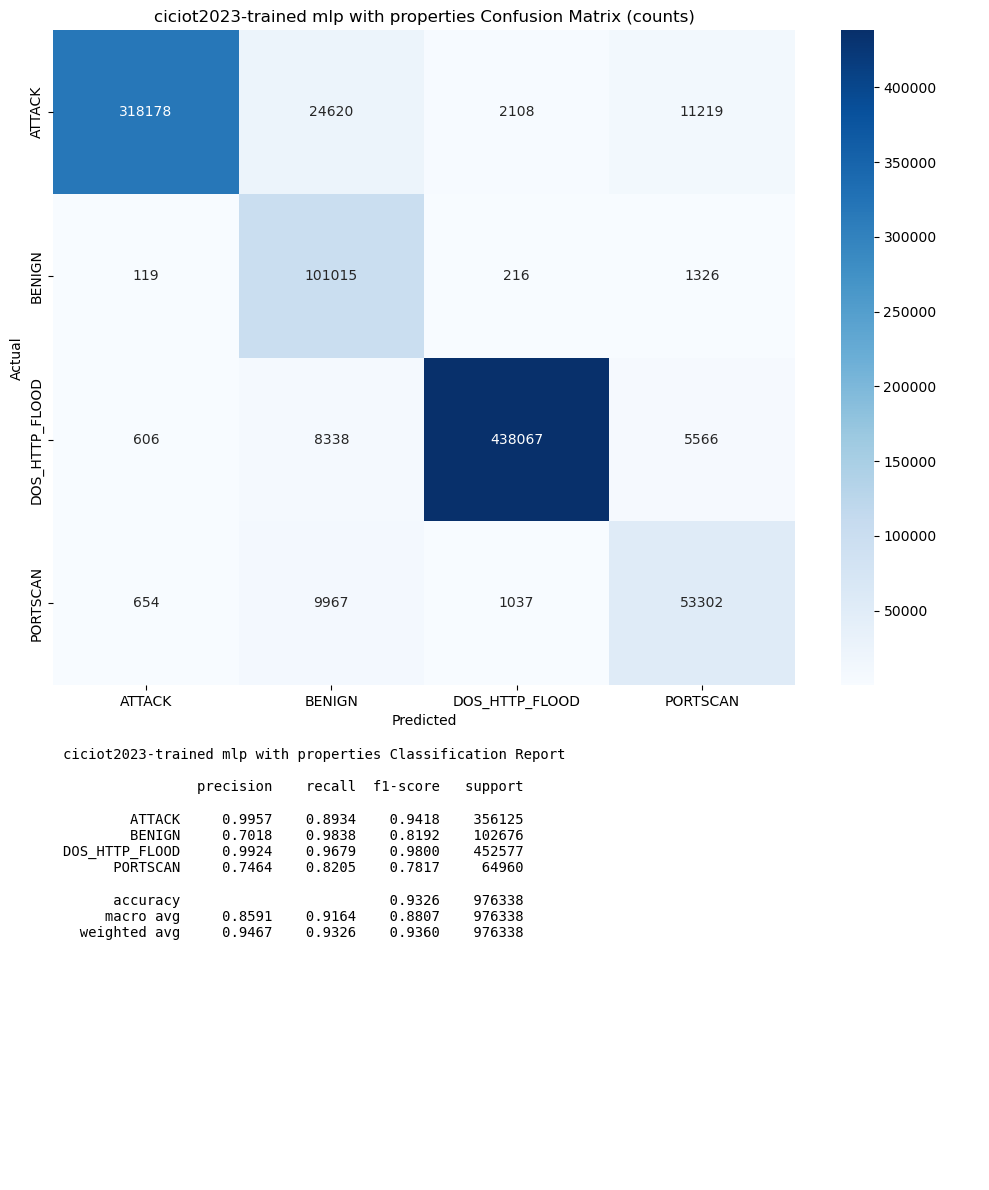


Saved model to: models/mlp_property_ciciot2023.joblib


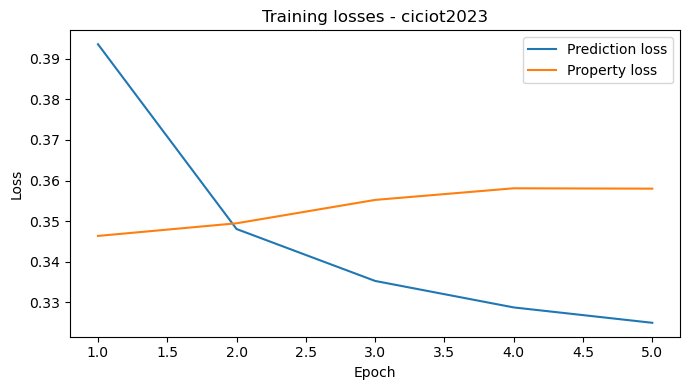

In [6]:
from datetime import date


for MODEL_TYPE in MODEL_TYPES:
    for dataset_name, dataset_config in DATASETS.items():
        print("\n" + "=" * 70)
        print(f"TRAINING ON: {dataset_name.upper()}")
        print("=" * 70)

        df_train = dataset_config["data_train"].copy()
        df_test = dataset_config["data_test"].copy()

        X_train = df_train[FEATURES]
        X_test = df_test[FEATURES]
        y_train = df_train["label"]
        y_test = df_test["label"]

        feature_cols = [c for c in FEATURES if c in df_train.columns]

        print("Shape:", df_train.shape)
        print(df_train["label"].value_counts())
        print("Features:", len(feature_cols))
        print(feature_cols)

        label_encoder = LabelEncoder()
        y_train_enc = label_encoder.fit_transform(y_train)
        y_test_enc = label_encoder.transform(y_test)

        X_train_bal = X_train.copy()
        X_test_local = X_test.copy()

        categorical_cols = X_train_bal.select_dtypes(include=["object", "string", "bool"]).columns.tolist()
        ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

        if len(categorical_cols) > 0:
            X_train_bal[categorical_cols] = ordinal_encoder.fit_transform(X_train_bal[categorical_cols])
            X_test_local[categorical_cols] = ordinal_encoder.transform(X_test_local[categorical_cols])

        binary_cols = [c for c in ["valid_tcp_handshake_feature", "is_udp", "is_http"] if c in feature_cols]
        continuous_cols = [c for c in feature_cols if c not in binary_cols]

        X_train_scaled_df = X_train_bal.copy()
        X_test_scaled_df = X_test_local.copy()

        scaler = StandardScaler()

        # Fit on ALL features
        X_train_scaled_df[feature_cols] = scaler.fit_transform(X_train_bal[feature_cols])
        X_test_scaled_df[feature_cols] = scaler.transform(X_test_local[feature_cols])

        # Restore binary columns to original 0/1 values
        for col in binary_cols:
            X_train_scaled_df[col] = X_train_bal[col].values
            X_test_scaled_df[col] = X_test_local[col].values

        # binary_cols are left untouched
        X_train_scaled = X_train_scaled_df[feature_cols].values
        X_test_scaled = X_test_scaled_df[feature_cols].values

        X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
        X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)

        y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
        y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

        num_classes = len(label_encoder.classes_)
        model = build_model(
            model_type=MODEL_TYPE,
            n_features=len(feature_cols),
            num_classes=num_classes,
        ).to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

        properties = build_properties(
            device=device,
            scaler=scaler,
            feature_names=feature_cols,
            label_encoder=label_encoder,
            logic=pml_logics.DL2()
        )

        x_batch, _ = next(iter(train_loader))
        x_batch = x_batch.to(device)
        total_loss, total_sat, prop_stats = properties.compute_loss(model, x_batch)

        print("Initial property loss: ", total_loss.item())
        print("Initial property sat: ", total_sat.item())
        print("Property stats:", prop_stats)

        history = []

        for epoch in range(NUM_EPOCHS):
            model.train()

            pred_losses = []
            prop_losses = []
            last_stats = {}

            for x_batch, y_batch in train_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                optimizer.zero_grad()

                logits = model(x_batch)
                pred_loss = criterion(logits, y_batch)

                total_loss, total_sat, prop_stats = properties.compute_loss(model, x_batch)
                
                # For the first few epochs, focus on prediction loss to allow the model to learn basic patterns. 
                # After that, start incorporating the property loss to guide the model towards satisfying the properties.
                # if epoch < 3:
                #     loss = pred_loss
                # else:
                loss = pred_loss + LAMBDA_PROP * total_loss
                loss.backward()
                optimizer.step()

                pred_losses.append(pred_loss.item())
                prop_losses.append(total_loss.item())
                last_stats = prop_stats

            avg_pred_loss = float(np.mean(pred_losses))
            avg_prop_loss = float(np.mean(prop_losses))

            history.append({
                "epoch": epoch + 1,
                "pred_loss": avg_pred_loss,
                "prop_loss": avg_prop_loss,
                **last_stats,
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"pred_loss={avg_pred_loss:.4f} | "
                f"prop_loss={avg_prop_loss:.4f} | "
                f"{', '.join(f'{k}={v:.4f}' for k, v in last_stats.items())}"
            )

        # evaluation
        model.eval()
        all_preds = []
        all_true = []

        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_batch = x_batch.to(device)

                logits = model(x_batch)
                preds = torch.argmax(logits, dim=1).cpu().numpy()

                all_preds.extend(preds)
                all_true.extend(y_batch.cpu().numpy())

        y_true_labels = label_encoder.inverse_transform(np.array(all_true))
        y_pred_labels = label_encoder.inverse_transform(np.array(all_preds))

        evaluate_model(
            y_true_labels,
            y_pred_labels,
            model_name=f"{dataset_name}-trained {MODEL_TYPE} with properties",
            path_to_save=f"{date.today()}/train_with_properties_evaluation_results"
        )

        os.makedirs("models", exist_ok=True)
        save_path = f"models/{MODEL_TYPE}_property_{dataset_name}.joblib"

        joblib.dump(
            {
                "model": model.cpu(),
                "ordinal_encoder": ordinal_encoder,
                "scaler": scaler,
                "label_encoder": label_encoder,
                "features": feature_cols,
                "categorical_cols": list(categorical_cols),
            },
            save_path,
        )

        print(f"\nSaved model to: {save_path}")

        history_df = pd.DataFrame(history)
        plt.figure(figsize=(7, 4))
        plt.plot(history_df["epoch"], history_df["pred_loss"], label="Prediction loss")
        plt.plot(history_df["epoch"], history_df["prop_loss"], label="Property loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"Training losses - {dataset_name}")
        plt.legend()
        plt.tight_layout()
        plt.show()

# Cross-data Eval

In [7]:
from utils.evaluation import (
    load_and_evaluate_model
)

In [8]:
df_cicids_combined = pd.read_csv("../data/cicids_combined_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
df_ciciot2023 = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")

In [9]:
df_cicids_combined_filtered = filter_labels(df_cicids_combined, TARGET_LABELS)
df_ciciot2023_filtered = filter_labels(df_ciciot2023, TARGET_LABELS)

In [10]:
DATASETS_EVAL = {
    "cicids_combined": {"X": df_cicids_combined_filtered[FEATURES], "y": df_cicids_combined_filtered["label"]},
    "ciciot2023": {"X": df_ciciot2023_filtered[FEATURES], "y": df_ciciot2023_filtered["label"]},
}
MODEL_TYPES_EVAL = [ 
    "mlp", 
    # "cnnlstm"
]


EVALUATING CICIDS_COMBINED-MLP ON CICIOT2023

=== CICIDS_COMBINED-MLP TESTED ON CICIOT2023 Classification Report ===

                precision    recall  f1-score   support

        ATTACK     0.1024    0.0239    0.0388   1187082
        BENIGN     0.1950    0.7948    0.3132    342255
DOS_HTTP_FLOOD     0.7843    0.0308    0.0593   1508589
      PORTSCAN     0.1123    0.7896    0.1966    216533

      accuracy                         0.1591   3254459
     macro avg     0.2985    0.4098    0.1520   3254459
  weighted avg     0.4289    0.1591    0.0877   3254459

Overall Accuracy: 0.1591

=== Per-Label Accuracy ===

ATTACK: 0.0239
BENIGN: 0.7948
DOS_HTTP_FLOOD: 0.0308
PORTSCAN: 0.7896


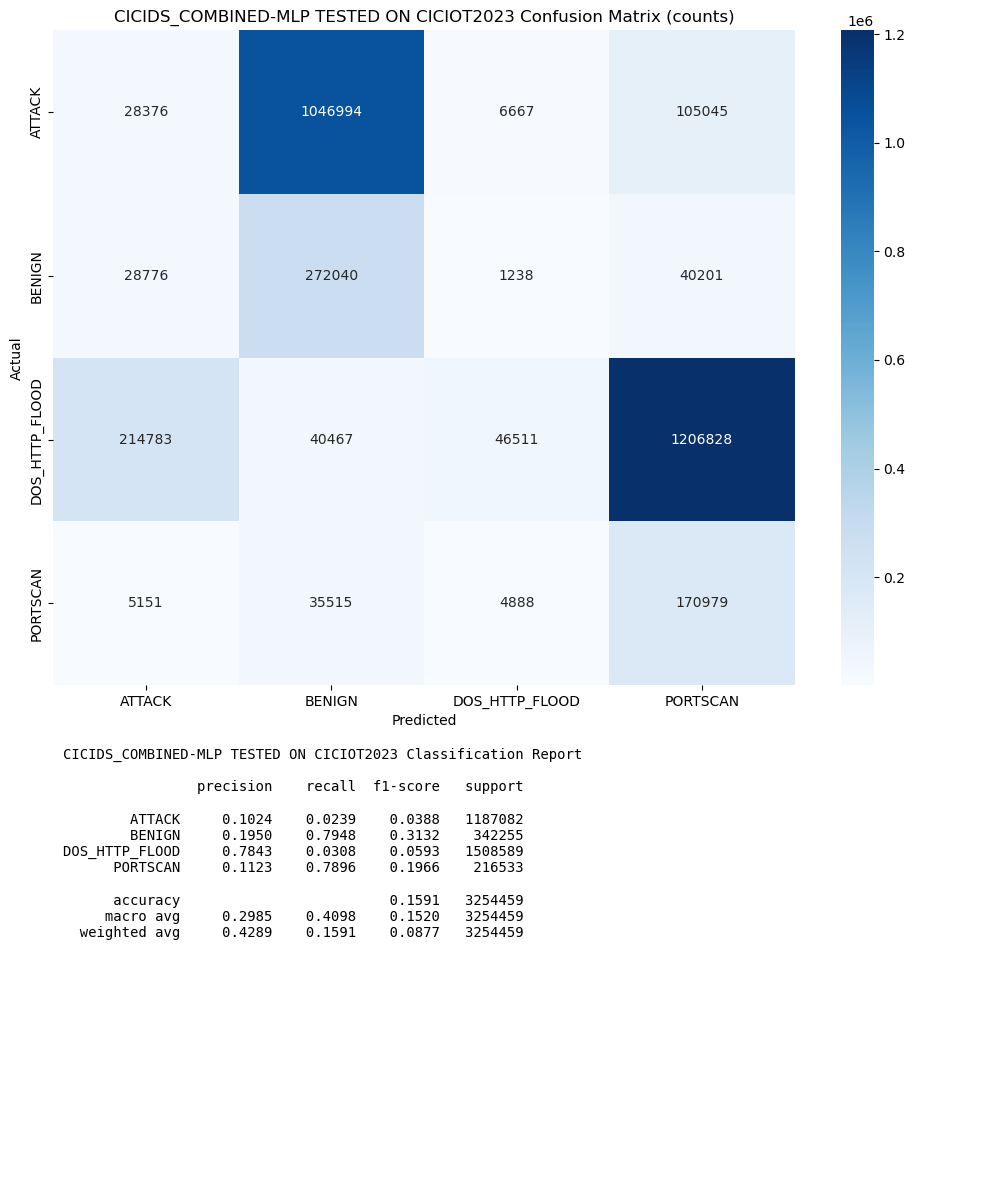


EVALUATING CICIOT2023-MLP ON CICIDS_COMBINED

=== CICIOT2023-MLP TESTED ON CICIDS_COMBINED Classification Report ===

                precision    recall  f1-score   support

        ATTACK     0.6111    0.2849    0.3886   8869735
        BENIGN     0.9130    0.0259    0.0503   2566701
DOS_HTTP_FLOOD     0.5491    0.9943    0.7075    154769
      PORTSCAN     0.0212    0.9965    0.0414    154034

      accuracy                         0.2470  11745239
     macro avg     0.5236    0.5754    0.2970  11745239
  weighted avg     0.6685    0.2470    0.3144  11745239

Overall Accuracy: 0.2470

=== Per-Label Accuracy ===

ATTACK: 0.2849
BENIGN: 0.0259
DOS_HTTP_FLOOD: 0.9943
PORTSCAN: 0.9965


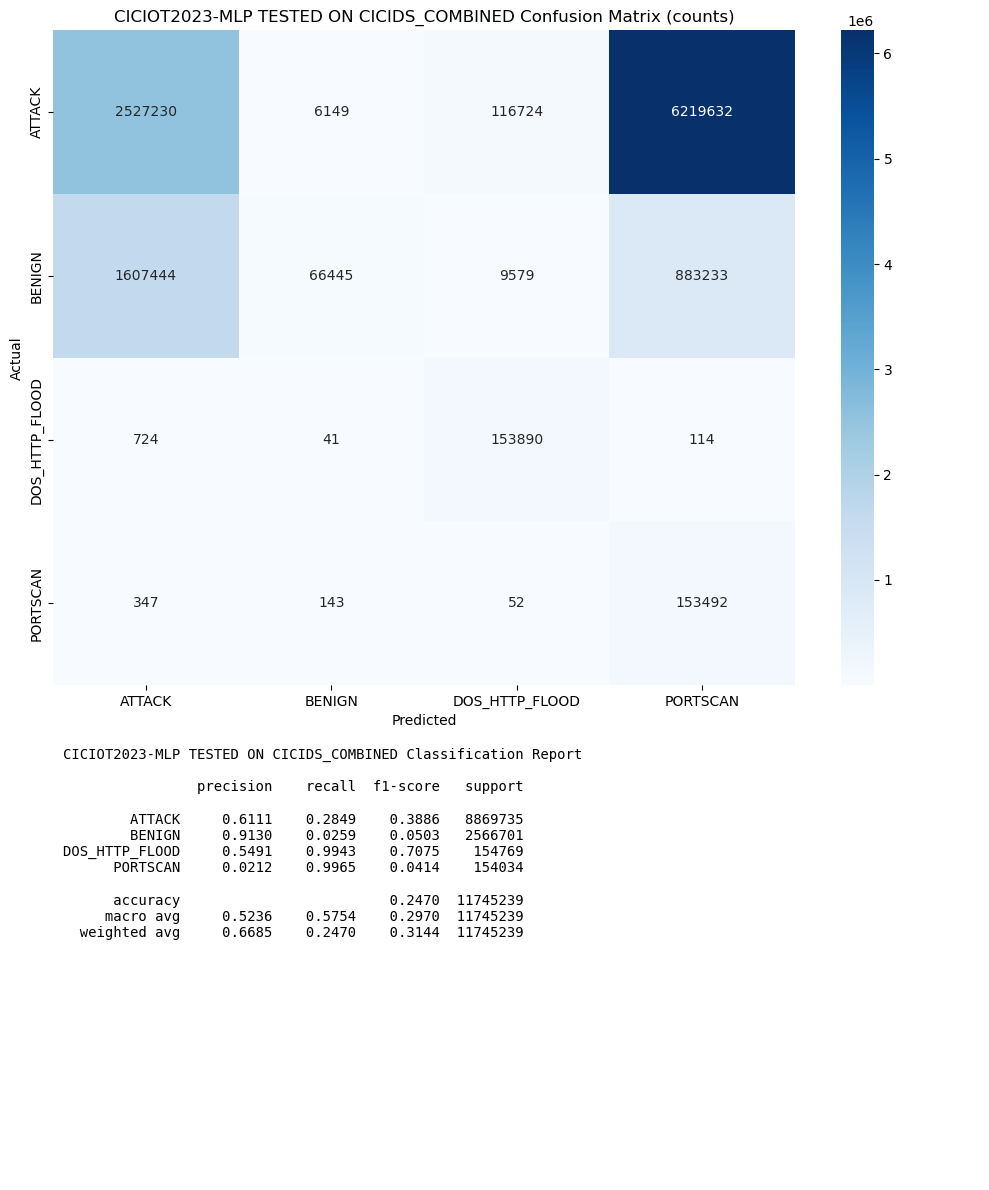

In [11]:
for MODEL_TYPE in MODEL_TYPES_EVAL:
    for dataset_name, dataset_config in DATASETS_EVAL.items():
        if dataset_name == "cicids_combined":
            X_test = DATASETS_EVAL["ciciot2023"]["X"]
            y_test = DATASETS_EVAL["ciciot2023"]["y"]
            test_name = "CICIOT2023"
        else:
            X_test = DATASETS_EVAL["cicids_combined"]["X"]
            y_test = DATASETS_EVAL["cicids_combined"]["y"]
            test_name = "CICIDS_COMBINED"
        print("\n" + "=" * 70)
        print(f"EVALUATING {dataset_name.upper()}-{MODEL_TYPE.upper()} ON {test_name}")
        print("=" * 70)
        joblib_path = f"models/{MODEL_TYPE}_property_{dataset_name}.joblib"
        load_and_evaluate_model(
            joblib_path=joblib_path,
            X=X_test,
            y_true=y_test,
            model_name=f"{dataset_name.upper()}-{MODEL_TYPE.upper()} TESTED ON {test_name}",
            batch_size=1024,
            path_to_save=f"{date.today()}/cross_dataset_evaluation_results",
        )